# DecodeLabs Project 2
## Supervised Learning — Fraud Detection Pipeline

This project builds a supervised machine learning pipeline for detecting potentially fraudulent e-commerce transactions.

The workflow includes:
- Data loading and exploration
- Synthetic fraud-label creation for educational purposes
- Data preprocessing
- Train-test splitting
- SMOTE for class imbalance
- Logistic Regression
- Random Forest
- Precision, Recall and ROC-AUC evaluation
- Model comparison

## 1. Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, machine learning, class-imbalance handling, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the E-Commerce Dataset

The dataset is loaded from a CSV file stored in the same project folder as this notebook.

In [2]:
df = pd.read_csv("fraud_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 1200
Columns: 14


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 3. Explore the Dataset

The dataset structure is examined to understand its dimensions, column names, data types, and statistical information before building the machine learning model.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe(include="all"))

Dataset Shape:
(1200, 14)

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

S

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,671,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD200000,2023-08-20,C38840,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK37947903,NaN,FREESHIP,Instagram,NaN
freq,1,8,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,NaN,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
std,NaN,NaN,NaN,NaN,1.407557,197.177146,NaN,NaN,NaN,NaN,2.281983,NaN,NaN,819.856558
min,NaN,NaN,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,NaN,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,NaN,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,NaN,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000


## 4. Standardize Column Names

Column names are cleaned by removing unnecessary spaces and converting them into a consistent format. This makes them easier to use in Python code.

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


## 5. Create a Synthetic Fraud Target

The provided e-commerce dataset does not contain a genuine fraud label.

Therefore, for educational demonstration of the supervised-learning pipeline, a synthetic fraud indicator is created using unusual transaction characteristics.

The generated `Fraud` column is a proxy label and must not be interpreted as verified real-world fraud.

In [5]:
# Convert relevant columns to numeric values
df["TotalPrice"] = pd.to_numeric(df["TotalPrice"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["ItemsInCart"] = pd.to_numeric(df["ItemsInCart"], errors="coerce")

# Calculate extreme transaction thresholds
price_threshold = df["TotalPrice"].quantile(0.95)
quantity_threshold = df["Quantity"].quantile(0.90)

# Create a synthetic/proxy fraud label
df["Fraud"] = (
    (df["TotalPrice"] >= price_threshold) &
    (df["Quantity"] >= quantity_threshold)
).astype(int)

print("Synthetic fraud label created.")
print("\nFraud distribution:")
print(df["Fraud"].value_counts())

print("\nFraud percentage:")
print(df["Fraud"].value_counts(normalize=True) * 100)

Synthetic fraud label created.

Fraud distribution:
Fraud
0    1153
1      47
Name: count, dtype: int64

Fraud percentage:
Fraud
0    96.083333
1     3.916667
Name: proportion, dtype: float64


## 6. Analyze Class Imbalance

Fraud detection datasets are commonly imbalanced because fraudulent transactions represent a much smaller portion of all transactions.

The class distribution is visualized before applying SMOTE.

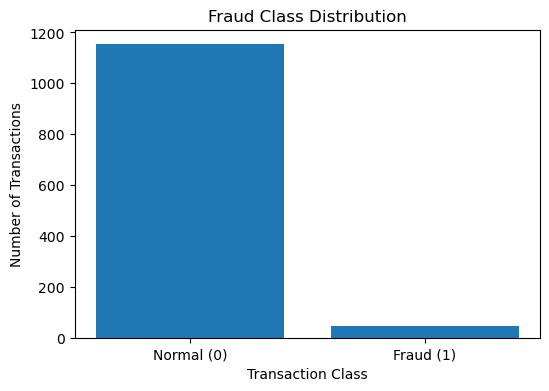

In [6]:
class_counts = df["Fraud"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Normal (0)", "Fraud (1)"],
    class_counts.values
)

plt.title("Fraud Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

## 7. Prepare Features and Target

The target variable is `Fraud`.

The columns used to directly create the synthetic fraud label are excluded from the model to reduce target leakage.

Identifiers and tracking information are also excluded because they do not provide useful generalizable predictive information.

In [7]:
target = "Fraud"

drop_columns = [
    "Fraud",
    "TotalPrice",
    "Quantity",
    "OrderID",
    "CustomerID",
    "TrackingNumber"
]

X = df.drop(columns=drop_columns, errors="ignore")
y = df[target]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature columns:
['Date', 'Product', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'ItemsInCart', 'CouponCode', 'ReferralSource']

Target distribution:
Fraud
0    1153
1      47
Name: count, dtype: int64


## 8. Split the Dataset

The dataset is divided into training and testing sets.

The training data is used to learn the machine learning models, while the testing data is kept separate for unbiased evaluation.

Stratification is used to preserve the fraud/non-fraud class proportions.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

Training samples: 960
Testing samples: 240

Training class distribution:
Fraud
0    922
1     38
Name: count, dtype: int64


## 9. Identify Feature Types

Numeric and categorical columns require different preprocessing techniques.

Numeric columns are imputed and standardized, while categorical columns are imputed and one-hot encoded.

In [9]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['UnitPrice', 'ItemsInCart']

Categorical features:
['Date', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']


## 10. Build the Preprocessing Pipeline

The preprocessing pipeline handles missing values and converts categorical variables into numerical form.

Standardization is applied to numerical features so that they are suitable for Logistic Regression.

In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 11. Logistic Regression with SMOTE

Logistic Regression is used as the baseline classification algorithm.

SMOTE is applied only to the training data through the machine learning pipeline. This prevents information from the test set from being used during oversampling.

In [12]:
logistic_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 12. Evaluate Logistic Regression

The Logistic Regression model is evaluated using Precision, Recall, and ROC-AUC.

Accuracy is deliberately not used as the primary metric because the project specifically focuses on imbalanced fraud detection.

In [13]:
logistic_predictions = logistic_pipeline.predict(X_test)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression Results")
print("-" * 35)
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"ROC-AUC   : {logistic_roc_auc:.4f}")

Logistic Regression Results
-----------------------------------
Precision : 0.2500
Recall    : 0.4444
ROC-AUC   : 0.9221


## 13. Random Forest with SMOTE

Random Forest is used as the second classification algorithm.

It combines multiple decision trees and can capture nonlinear relationships between transaction characteristics.

In [14]:
random_forest_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## 14. Evaluate Random Forest

The Random Forest model is evaluated using Precision, Recall, and ROC-AUC to determine how effectively it identifies the synthetic fraud class.

In [15]:
rf_predictions = random_forest_pipeline.predict(X_test)
rf_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest Results")
print("-" * 35)
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

Random Forest Results
-----------------------------------
Precision : 0.0000
Recall    : 0.0000
ROC-AUC   : 0.9221


## 15. Confusion Matrix

A confusion matrix is used to examine how many transactions were correctly and incorrectly classified as normal or fraudulent.

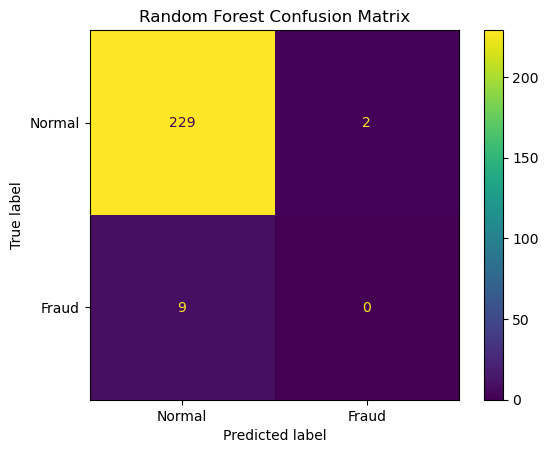

In [16]:
cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

## 16. Classification Report

The classification report provides Precision, Recall, F1-score, and support for each class.

Precision and Recall are particularly important for the fraud-detection problem.

In [17]:
print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       231
       Fraud       0.00      0.00      0.00         9

    accuracy                           0.95       240
   macro avg       0.48      0.50      0.49       240
weighted avg       0.93      0.95      0.94       240



## 17. Compare Logistic Regression and Random Forest

The two supervised learning algorithms are compared using the required evaluation metrics: Precision, Recall, and ROC-AUC.

Higher values indicate stronger performance for the corresponding metric.

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ]
})

comparison

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.25,0.444444,0.922078
1,Random Forest,0.00,0.000000,0.922078


## 18. Visual Model Comparison

The evaluation metrics of both models are visualized to make the comparison easier.

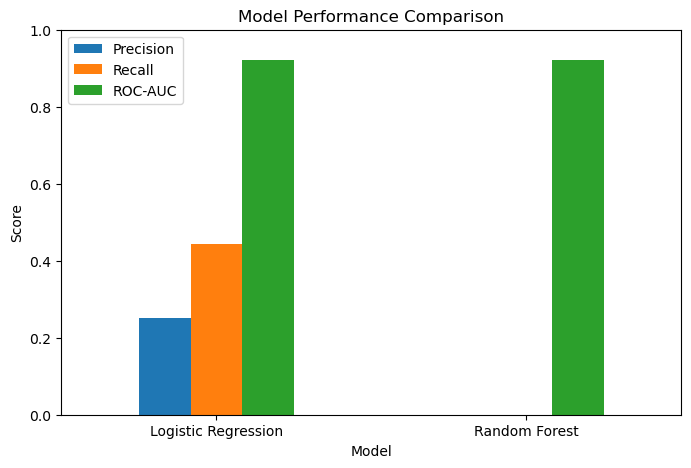

In [19]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

## 19. Select the Better Model

The model with the higher ROC-AUC is selected as the stronger overall classifier for this experiment.

ROC-AUC is used as the main comparison metric because the project focuses on classification performance in an imbalanced setting.

In [20]:
if rf_roc_auc > logistic_roc_auc:
    best_model = "Random Forest"
    best_score = rf_roc_auc
else:
    best_model = "Logistic Regression"
    best_score = logistic_roc_auc

print("Best Model:", best_model)
print(f"ROC-AUC: {best_score:.4f}")

Best Model: Logistic Regression
ROC-AUC: 0.9221


## 20. Save Model Evaluation Results

The model comparison results are saved as a CSV file so that the results can be included with the final project.

In [21]:
comparison.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


## Conclusion

This project implemented a supervised learning fraud-detection pipeline using an e-commerce dataset.

The workflow included data preprocessing, train-test splitting, SMOTE-based handling of class imbalance, Logistic Regression, and Random Forest classification.

The models were evaluated using Precision, Recall, and ROC-AUC instead of relying on Accuracy, following the requirements of DecodeLabs Project 2.

Because the provided dataset did not contain a verified fraud label, a synthetic proxy fraud target was created for educational purposes. Therefore, the resulting model performance should be interpreted as a demonstration of the machine-learning pipeline rather than as evidence of real-world fraud-detection performance.

# DecodeLabs Project 2 — Supervised Learning Fraud Detection Pipeline

## Project Overview

This project implements a supervised machine learning pipeline for detecting potentially fraudulent e-commerce transactions.

The project was completed as part of the DecodeLabs Data Science Project 2 training task.

The main objective is to demonstrate how classification algorithms can be applied to an imbalanced transaction dataset using appropriate preprocessing, SMOTE oversampling, and evaluation metrics.

## Project Requirements

The project focuses on:

* Handling imbalanced data using SMOTE
* Training Logistic Regression
* Training Random Forest
* Evaluating models using Precision
* Evaluating models using Recall
* Evaluating models using ROC-AUC
* Comparing the performance of multiple classification algorithms

Accuracy was not used as the primary evaluation metric because the project specifically focuses on imbalanced fraud-detection data.

## Dataset

The project uses the provided e-commerce transaction dataset.

The dataset contains transaction-related information such as:

* Order ID
* Date
* Customer ID
* Product
* Quantity
* Unit Price
* Shipping Address
* Payment Method
* Order Status
* Tracking Number
* Items in Cart
* Coupon Code
* Referral Source
* Total Price

## Important Note About the Fraud Label

The provided e-commerce dataset does not contain a verified real-world fraud label.

Therefore, a synthetic/proxy `Fraud` target was created for educational purposes using unusual transaction characteristics.

The generated fraud label should not be interpreted as confirmed real-world fraudulent activity.

This approach allows the complete supervised-learning pipeline required by the project to be demonstrated while clearly distinguishing the experiment from a real fraud-detection system.

## Methodology

### 1. Data Loading

The CSV dataset is loaded using Pandas.

### 2. Data Exploration

The dataset is examined for:

* Shape
* Column names
* Data types
* Missing values
* Statistical information

### 3. Target Creation

A synthetic `Fraud` target is created because the original dataset does not contain a fraud label.

### 4. Feature Preparation

Identifiers and variables directly used to create the synthetic target are excluded to reduce target leakage.

### 5. Train-Test Split

The dataset is divided into training and testing data using a stratified split.

### 6. Preprocessing

Numeric features are processed using median imputation and standardization.

Categorical features are processed using most-frequent imputation and one-hot encoding.

### 7. SMOTE

SMOTE is applied to the training data to increase representation of the minority fraud class.

SMOTE is applied inside the machine-learning pipeline so that the test dataset remains untouched.

### 8. Logistic Regression

Logistic Regression is trained as a baseline classification model.

### 9. Random Forest

Random Forest is trained as a second classification model capable of learning nonlinear relationships between features.

### 10. Model Evaluation

The models are evaluated using:

* Precision
* Recall
* ROC-AUC

A confusion matrix and classification report are also generated.

## Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Scikit-learn
* Imbalanced-learn
* SMOTE
* Logistic Regression
* Random Forest
* Jupyter Notebook
* Visual Studio Code
* Git
* GitHub

## Project Files

```text
DecodeLabs_Project2/
│
├── Fraud_Detection_Pipeline.ipynb
├── fraud_dataset.csv
├── model_comparison_results.csv
└── README.md
```

## Expected Outcome

The project produces two trained classification models and compares their Precision, Recall, and ROC-AUC performance.

The model with the stronger ROC-AUC score is identified as the better-performing model for this experiment.

## Conclusion

This project demonstrates a complete supervised-learning workflow for an imbalanced fraud-detection problem.

The implementation covers data preparation, feature preprocessing, SMOTE-based class balancing, Logistic Regression, Random Forest, and model evaluation using appropriate classification metrics.

Since the fraud target is synthetic, the results demonstrate the machine-learning methodology rather than representing validated real-world fraud predictions.
